### Imports

In [ ]:
# train.csv
! gdown 19gyTA8S9wXPlxkyU0mZ_raJO62ny-vpo

# test.csv
! gdown 1NqChJSt70NvgInNvYEyh2GTsBfpXUNuj

# Download dataset
! gdown 1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI

# Unzip
! tar -xzf "CrisisMMD_v2.0.tar.gz"

Downloading...
From: https://drive.google.com/uc?id=19gyTA8S9wXPlxkyU0mZ_raJO62ny-vpo
To: /content/train.csv
100% 988k/988k [00:00<00:00, 12.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NqChJSt70NvgInNvYEyh2GTsBfpXUNuj
To: /content/test.csv
100% 421k/421k [00:00<00:00, 6.78MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI
From (redirected): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI&confirm=t&uuid=f431fdb5-9ec4-4235-a104-7e5946c9d213
To: /content/CrisisMMD_v2.0.tar.gz
100% 1.90G/1.90G [00:19<00:00, 98.3MB/s]


In [ ]:
from google.colab import drive
from pathlib import Path
import os, sys

drive.mount('/content/drive')

DRIVE_CKPT = Path('/content/drive/MyDrive/checkpoints')
DRIVE_CKPT.mkdir(parents=True, exist_ok=True)
TEXT_CKPT_DIR = DRIVE_CKPT / 'text_branch'
TEXT_CKPT_DIR.mkdir(parents=True, exist_ok=True)

if not os.path.exists('/content/Data-Science-Project'):
    !git clone https://github.com/brian-w-zhang/Data-Science-Project.git

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)
print('text checkpoint dir:', TEXT_CKPT_DIR)

Mounted at /content/drive
Cloning into 'Data-Science-Project'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 138 (delta 65), reused 90 (delta 31), pack-reused 6 (from 1)
Receiving objects: 100% (138/138), 6.75 MiB | 14.20 MiB/s, done.
Resolving deltas: 100% (66/66), done.
/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project
text checkpoint dir: /content/drive/MyDrive/checkpoints/text_branch


### Load and tokenize combined Kaggle + CrisisMMD dataset

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, get_cosine_schedule_with_warmup

from data.kaggle_text import load_kaggle_disaster_csv, clean_tweet
from data.crisismmd import load_crisismmd_annotations
from models.text_branch import create_text_classifier, TextDatasetWrapper, TextClassificationWrapper
from training.utils import train_one_epoch, evaluate

In [ ]:
# ── 1. Load Kaggle disaster tweets ────────────────────────────────────────────
kaggle_df = pd.read_csv("/content/train.csv")[["text", "target"]].dropna()  # adjust path if needed
kaggle_df = kaggle_df.rename(columns={"target": "label"})
kaggle_df["text"]   = kaggle_df["text"].apply(clean_tweet)
kaggle_df["source"] = "kaggle"

# Balance Kaggle 50/50, then cap each class at 5000
k_pos = kaggle_df[kaggle_df.label == 1]
k_neg = kaggle_df[kaggle_df.label == 0]
k_n   = min(len(k_pos), len(k_neg), 5000)
kaggle_balanced = pd.concat([
    k_pos.sample(k_n, random_state=42),
    k_neg.sample(k_n, random_state=42),
])

# ── 2. Load CrisisMMD text ─────────────────────────────────────────────────────
# Use text_info as label (not the OR-label used by the fusion model),
# since we are training a text-only branch here.
combined_cmmd = load_crisismmd_annotations("/content/CrisisMMD_v2.0")  # adjust path if needed
cmmd_df = combined_cmmd[["tweet_text", "text_info"]].dropna().drop_duplicates(subset="tweet_text")
cmmd_df["label"]  = (cmmd_df["text_info"] == "informative").astype(int)
cmmd_df = cmmd_df.rename(columns={"tweet_text": "text"})
cmmd_df["text"]   = cmmd_df["text"].apply(clean_tweet)
cmmd_df["source"] = "crisismmd"

# Balance CrisisMMD 50/50, cap each class at 5000
c_pos = cmmd_df[cmmd_df.label == 1]
c_neg = cmmd_df[cmmd_df.label == 0]
c_n   = min(len(c_pos), len(c_neg), 5000)
cmmd_balanced = pd.concat([
    c_pos.sample(c_n, random_state=42),
    c_neg.sample(c_n, random_state=42),
])

# ── 3. Combine and split ────────────────────────────────────────────────────────
# Shuffle combined pool; stratified 80/20 split preserves 50/50 balance in both splits
combined_df = pd.concat([cmmd_balanced, kaggle_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Total samples:",  len(combined_df))
print("Label distribution:\n",  combined_df["label"].value_counts())
print("Source distribution:\n", combined_df["source"].value_counts())

# Convert to HuggingFace Dataset and do a stratified 80/20 split
from datasets import ClassLabel, Value

hf_dataset = Dataset.from_pandas(combined_df[["text", "label"]])
hf_dataset = hf_dataset.cast_column("label", ClassLabel(names=["not_disaster", "disaster"]))
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")
train_ds_raw = hf_dataset["train"]
val_ds_raw   = hf_dataset["test"]

# Create model & tokenizer
model_hf, tokenizer = create_text_classifier(num_labels=2)

# Tokenization function
def tokenize_batch(batch):
    out = tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )
    out["label"] = batch["label"]
    return out

tokenized    = hf_dataset.map(tokenize_batch, batched=True)
train_ds_tok = tokenized["train"]
val_ds_tok   = tokenized["test"]

# Keep only the needed columns and set PyTorch format
columns = ["input_ids", "attention_mask", "label"]
train_ds_tok.set_format(type="torch", columns=columns)
val_ds_tok.set_format(type="torch", columns=columns)


Total samples: 15652
Label distribution:
 label
1    7826
0    7826
Name: count, dtype: int64
Source distribution:
 source
crisismmd    9110
kaggle       6542
Name: count, dtype: int64


Casting the dataset:   0%|          | 0/15652 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/12521 [00:00<?, ? examples/s]

Map:   0%|          | 0/3131 [00:00<?, ? examples/s]

### Wrap dataset

In [ ]:
# Wrap the HF datasets so each batch is: ((input_ids, attention_mask), label)

train_wrapped = TextDatasetWrapper(train_ds_tok)
val_wrapped   = TextDatasetWrapper(val_ds_tok)

train_loader = DataLoader(train_wrapped, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_wrapped,   batch_size=16, shuffle=False)

### Build model, optimizer and scheduler

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TextClassificationWrapper(model_hf).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.1)

EPOCHS  = 10
PATIENCE = 3

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

train_loss_hist, train_acc_hist = [], []
val_loss_hist,   val_acc_hist   = [], []

best_val_f1      = 0.0
patience_counter = 0
best_epoch       = 0

print(f'Using device: {device}')
print(f'Total steps: {total_steps}, Warmup steps: {warmup_steps}')

Using device: cuda
Total steps: 7830, Warmup steps: 783


### Training loop

In [ ]:
os.makedirs('../checkpoints/text_branch', exist_ok=True)

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')

    train_loss, train_acc = train_one_epoch(
        model=model, loader=train_loader, optimizer=optimizer,
        criterion=criterion, device=device, scheduler=scheduler,
    )

    val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
        model=model, loader=val_loader, criterion=criterion, device=device,
    )

    val_f1 = f1_score(val_true, val_preds, average='macro')

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, '
        f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_macro_f1={val_f1:.4f}'
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch + 1
        patience_counter = 0
        model_hf.save_pretrained(str(TEXT_CKPT_DIR))
        tokenizer.save_pretrained(str(TEXT_CKPT_DIR))
        print(f'  ✓ New best saved to Drive (macro F1={val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best was epoch {best_epoch}.')
            break

print(f'\nDone. Best val macro F1: {best_val_f1:.4f} at epoch {best_epoch}')


Epoch 1/10


train_loss=0.5439, train_acc=0.7198, val_loss=0.4590, val_acc=0.7921, val_macro_f1=0.7920


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best saved to Drive (macro F1=0.7920)

Epoch 2/10


train_loss=0.4146, train_acc=0.8154, val_loss=0.4341, val_acc=0.8029, val_macro_f1=0.8028


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best saved to Drive (macro F1=0.8028)

Epoch 3/10


train_loss=0.3354, train_acc=0.8590, val_loss=0.4742, val_acc=0.7962, val_macro_f1=0.7962
  No improvement. Patience: 1/3

Epoch 4/10


train_loss=0.2435, train_acc=0.9076, val_loss=0.5219, val_acc=0.7918, val_macro_f1=0.7915
  No improvement. Patience: 2/3

Epoch 5/10


train_loss=0.1671, train_acc=0.9417, val_loss=0.6274, val_acc=0.7828, val_macro_f1=0.7826
  No improvement. Patience: 3/3

Early stopping at epoch 5. Best was epoch 2.

Done. Best val macro F1: 0.8028 at epoch 2


### Plot training/eval metrics

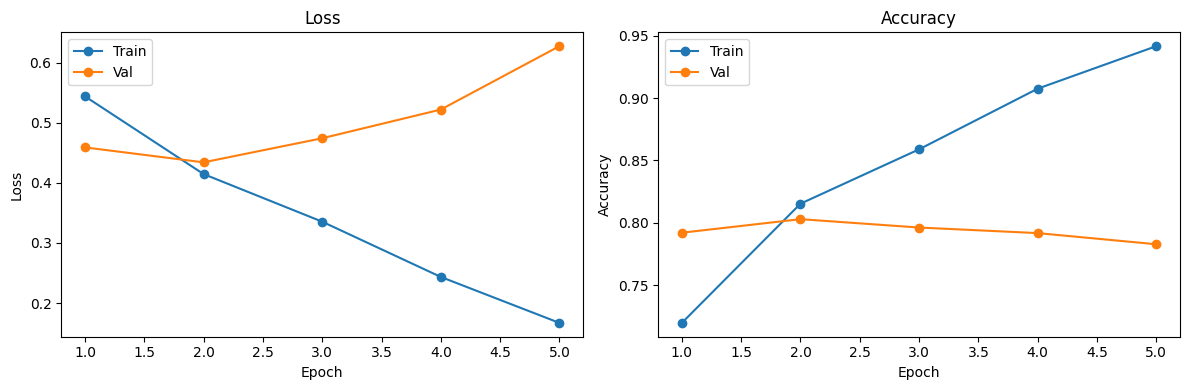

In [ ]:
epochs_ran = np.arange(1, len(train_loss_hist) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot(epochs_ran, train_loss_hist, marker='o', label='Train')
ax[0].plot(epochs_ran, val_loss_hist,   marker='o', label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy curves
ax[1].plot(epochs_ran, train_acc_hist, marker='o', label='Train')
ax[1].plot(epochs_ran, val_acc_hist,   marker='o', label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation on best checkpoint

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- DISTILBERT TEXT MODEL VALIDATION RESULTS ---
Val Accuracy:    80.29%
Val F1 (binary): 0.7976
Val F1 (macro):  0.8028
Val ROC-AUC:     0.8816


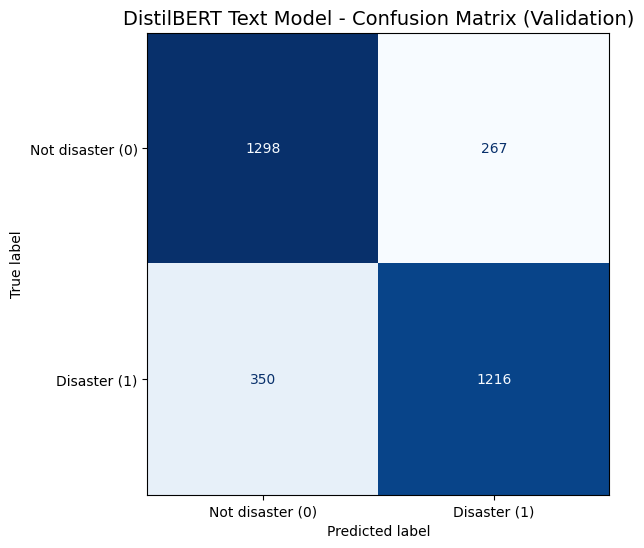

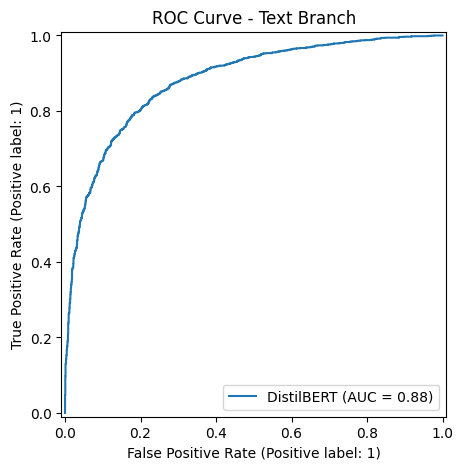

In [ ]:
# Load best checkpoint before final eval
# model_hf_best = AutoModelForSequenceClassification.from_pretrained('../checkpoints/text_branch')
model_hf_best = AutoModelForSequenceClassification.from_pretrained(str(TEXT_CKPT_DIR))
model = TextClassificationWrapper(model_hf_best).to(device)

val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
    model=model, loader=val_loader, criterion=criterion, device=device,
)

val_f1_macro  = f1_score(val_true, val_preds, average='macro')
val_f1_binary = f1_score(val_true, val_preds, average='binary')
val_roc_auc   = roc_auc_score(val_true, val_probs[:, 1])

print('\n--- DISTILBERT TEXT MODEL VALIDATION RESULTS ---')
print(f'Val Accuracy:    {val_acc * 100:.2f}%')
print(f'Val F1 (binary): {val_f1_binary:.4f}')
print(f'Val F1 (macro):  {val_f1_macro:.4f}')
print(f'Val ROC-AUC:     {val_roc_auc:.4f}')

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not disaster (0)', 'Disaster (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('DistilBERT Text Model - Confusion Matrix (Validation)', fontsize=14)
plt.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(val_true, val_probs[:, 1], ax=ax, name='DistilBERT')
ax.set_title('ROC Curve - Text Branch')
plt.show()